# Hotel Booking Demand - Cross-Technique Analysis

Notebook tổng hợp kết quả quan trọng của đồ án: kết hợp Classification và Clustering để nhận diện và giải thích rủi ro hủy booking.

## 1. Bài toán và câu hỏi phân tích

Mục tiêu là hỗ trợ khách sạn nhận diện sớm booking có nguy cơ hủy và hiểu nhóm hành vi đứng sau rủi ro đó.

1. Những đặc điểm nào của booking liên quan đến khả năng hủy?
2. Các booking có thể được chia thành những nhóm hành vi có mức rủi ro hủy khác nhau hay không?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE, DBSCAN_SAMPLE_N, DBSCAN_EPS = 42, 15000, 9.0

PROJECT_DIR = Path(".") if Path("data/hotel_bookings_processed.csv").exists() else Path("DO_AN")
DATA_PATH = PROJECT_DIR / "data" / "hotel_bookings_processed.csv"
METRICS_PATH = PROJECT_DIR / "data" / "D1_metrics.csv"
OUTPUT_DIR = PROJECT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Dữ liệu và kết quả kế thừa

Đồ án dùng dữ liệu D1 sau tiền xử lý. Classification kế thừa kết quả Bài 2; lựa chọn DBSCAN kế thừa đánh giá K-Means và DBSCAN ở Bài 4.

In [2]:
if not DATA_PATH.exists() or not METRICS_PATH.exists():
    raise FileNotFoundError("Thiếu dữ liệu D1 hoặc D1_metrics.csv trong thư mục DO_AN/data.")

df_raw = pd.read_csv(DATA_PATH)
d1_metrics = pd.read_csv(METRICS_PATH).sort_values("f1", ascending=False)

target_summary = (
    df_raw["is_canceled"].value_counts(normalize=True).mul(100)
    .rename_axis("is_canceled").reset_index(name="percent")
)
clustering_summary = pd.DataFrame({
    "Thuật toán": ["K-Means", "DBSCAN"],
    "Cấu hình": ["K=2", "eps=9.0, min_samples=88"],
    "Số cụm": [2, 3],
    "Silhouette": [0.2226, 0.4146],
    "Davies-Bouldin": [2.5680, 0.9486],
    "Noise (%)": [0.00, 1.72],
})

print(f"Dữ liệu sau Bài 1: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
display(Markdown("**Phân bố nhãn**"), target_summary.round(2))
display(Markdown("**Kết quả Classification từ Bài 2**"), d1_metrics.reset_index(drop=True))
display(Markdown("**Kết quả Clustering từ Bài 4**"), clustering_summary)

Dữ liệu sau Bài 1: 117,398 dòng x 43 cột


**Phân bố nhãn**

,is_canceled,percent
0,0,62.51
1,1,37.49


**Kết quả Classification từ Bài 2**

,dataset,model,accuracy,precision,recall,f1,roc_auc
0,D1,Decision Tree,0.788375,0.578752,0.850658,0.688844,0.890328
1,D1,Logistic Regression,0.748125,0.528852,0.782115,0.631020,0.841971


**Kết quả Clustering từ Bài 4**

,Thuật toán,Cấu hình,Số cụm,Silhouette,Davies-Bouldin,Noise (%)
0,K-Means,K=2,2,0.2226,2.5680,0.00
1,DBSCAN,"eps=9.0, min_samples=88",3,0.4146,0.9486,1.72


## 3. Chuẩn bị sample phân tích

DBSCAN được tái tạo với đúng cấu hình và seed của Bài 4 để gắn nhãn cluster cho 15.000 booking. `is_canceled` không được dùng làm đầu vào tạo cụm.

In [3]:
drop_cluster = [
    "is_canceled", "country", "agent", "company",
    "reserved_room_type", "assigned_room_type",
]
df_cluster = df_raw.drop(columns=drop_cluster, errors="ignore").copy()

month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
if "arrival_date_month" in df_cluster:
    df_cluster["arrival_date_month"] = df_cluster["arrival_date_month"].map(month_map)

encode_cols = [
    column for column in ["distribution_channel", "customer_type"]
    if column in df_cluster.columns
]
df_cluster = pd.get_dummies(df_cluster, columns=encode_cols, dtype=int)
object_cols = df_cluster.select_dtypes(include="object").columns.tolist()
if object_cols:
    raise ValueError(f"Còn cột chưa mã hóa: {object_cols}")

X_cluster = StandardScaler().fit_transform(df_cluster)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_cluster), DBSCAN_SAMPLE_N, replace=False)
X_sample = X_cluster[sample_idx]
min_samples = 2 * X_sample.shape[1]
sample_labels = DBSCAN(
    eps=DBSCAN_EPS, min_samples=min_samples, n_jobs=-1,
).fit_predict(X_sample)

df_analysis = df_raw.iloc[sample_idx].copy()
df_analysis["cluster"] = sample_labels
df_analysis["cluster_label"] = df_analysis["cluster"].map(
    lambda value: "noise" if value == -1 else f"cluster_{value}"
)
print(
    f"Sample: {len(df_analysis):,} | "
    f"Clusters: {len(set(sample_labels)) - (-1 in sample_labels)} | "
    f"Noise: {(sample_labels == -1).mean() * 100:.2f}%"
)

Sample: 15,000 | Clusters: 3 | Noise: 1.72%


## 4. Rủi ro hủy và profiling theo cluster

Nhãn hủy chỉ được ghép sau khi phân cụm để đo tỷ lệ hủy và mô tả đặc điểm của từng nhóm.

In [4]:
overall_cancel_rate = df_analysis["is_canceled"].mean()
cluster_summary = (
    df_analysis.groupby(["cluster", "cluster_label"])["is_canceled"]
    .agg(n="size", cancellations="sum", cancellation_rate="mean")
    .reset_index()
)
cluster_summary["share_percent"] = 100 * cluster_summary["n"] / len(df_analysis)
cluster_summary["cancellation_rate_percent"] = 100 * cluster_summary["cancellation_rate"]
cluster_summary["lift_vs_sample"] = cluster_summary["cancellation_rate"] / overall_cancel_rate

profile_cols = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "booking_changes",
    "days_in_waiting_list", "adr", "total_stay", "total_people",
    "total_of_special_requests",
]
overall_profile = df_analysis[profile_cols].mean()
profile_diff = (
    df_analysis.query("cluster != -1").groupby("cluster")[profile_cols].mean()
    .subtract(overall_profile, axis=1)
)

display(cluster_summary.round(3))

,cluster,cluster_label,n,cancellations,cancellation_rate,share_percent,cancellation_rate_percent,lift_vs_sample
0,-1,noise,258,56,0.217,1.720,21.705,0.574
1,0,cluster_0,14509,5524,0.381,96.727,38.073,1.007
2,1,cluster_1,134,37,0.276,0.893,27.612,0.731
3,2,cluster_2,99,52,0.525,0.660,52.525,1.390


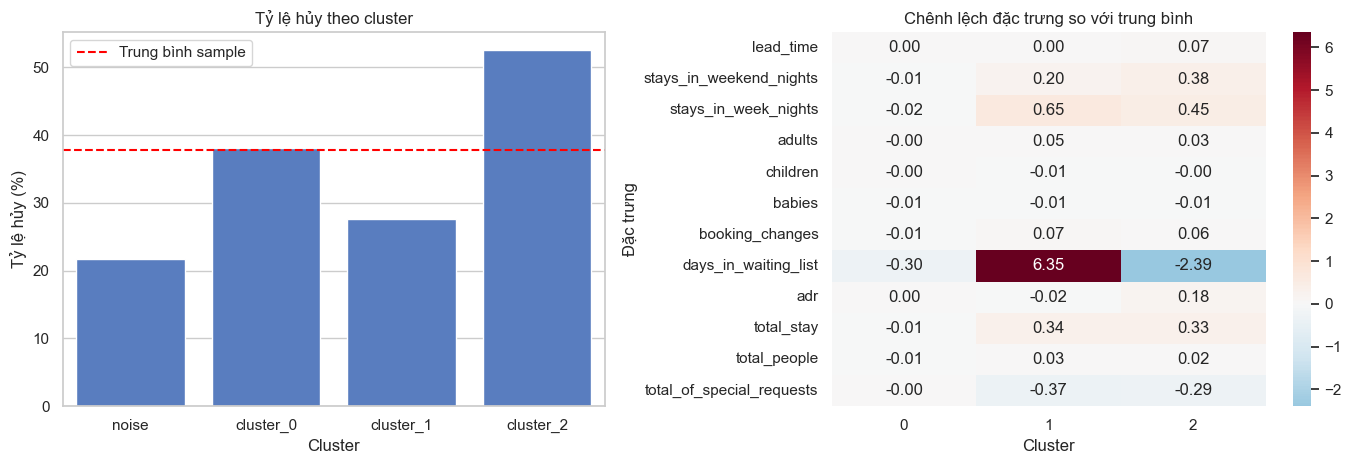

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(
    data=cluster_summary.sort_values("cluster"),
    x="cluster_label", y="cancellation_rate_percent", ax=axes[0],
)
axes[0].axhline(
    overall_cancel_rate * 100, color="red", linestyle="--", label="Trung bình sample"
)
axes[0].set(title="Tỷ lệ hủy theo cluster", xlabel="Cluster", ylabel="Tỷ lệ hủy (%)")
axes[0].legend()

sns.heatmap(profile_diff.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set(title="Chênh lệch đặc trưng so với trung bình", xlabel="Cluster", ylabel="Đặc trưng")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_cluster_risk_profile.png", dpi=300)
plt.show()

## 5. Tổng hợp Classification và Clustering

Decision Tree dùng cấu hình tốt nhất từ Bài 2. Dự đoán 5-fold out-of-fold được tạo trên đúng 15.000 booking của DBSCAN để đánh giá hai kỹ thuật trên cùng từng dòng mà không dự đoán lại dữ liệu đã học.

In [6]:
drop_classification = [
    "is_canceled", "cluster", "cluster_label", "assigned_room_type",
    "reservation_status", "reservation_status_date",
]
X_cls = df_analysis.drop(columns=drop_classification, errors="ignore")
y_cls = df_analysis["is_canceled"].astype(int)

num_cols = X_cls.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [column for column in X_cls.columns if column not in num_cols]
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ]), cat_cols),
])
tree_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(
        max_depth=14, min_samples_leaf=50,
        class_weight="balanced", random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
df_analysis["p_cancel"] = cross_val_predict(
    tree_pipeline, X_cls, y_cls, cv=cv, method="predict_proba", n_jobs=1,
)[:, 1]
df_analysis["y_pred"] = (df_analysis["p_cancel"] >= 0.5).astype(int)

print(
    f"OOF F1={f1_score(y_cls, df_analysis['y_pred']):.4f} | "
    f"ROC-AUC={roc_auc_score(y_cls, df_analysis['p_cancel']):.4f}"
)

OOF F1=0.7769 | ROC-AUC=0.9159


,cluster,cluster_label,n,hủy thực tế (%),xác suất dự đoán (%),precision,recall,f1,FP,FN
0,-1,noise,258,21.705,28.256,0.576,0.607,0.591,25,22
1,0,cluster_0,14509,38.073,43.262,0.727,0.838,0.779,1735,897
2,1,cluster_1,134,27.612,42.276,0.579,0.892,0.702,24,4
3,2,cluster_2,99,52.525,52.754,0.880,0.846,0.863,6,8


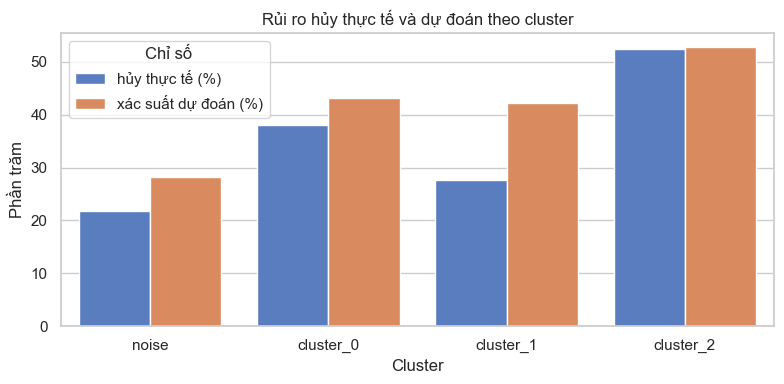

In [7]:
rows = []
for (cluster, label), group in df_analysis.groupby(["cluster", "cluster_label"]):
    y_true, y_pred = group["is_canceled"].astype(int), group["y_pred"]
    _, fp, fn, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rows.append({
        "cluster": cluster, "cluster_label": label, "n": len(group),
        "hủy thực tế (%)": 100 * y_true.mean(),
        "xác suất dự đoán (%)": 100 * group["p_cancel"].mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "FP": fp, "FN": fn,
    })

cluster_eval = pd.DataFrame(rows)
display(cluster_eval.round(3))

plot_data = cluster_eval.melt(
    id_vars="cluster_label",
    value_vars=["hủy thực tế (%)", "xác suất dự đoán (%)"],
    var_name="Chỉ số", value_name="Phần trăm",
)
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_data, x="cluster_label", y="Phần trăm", hue="Chỉ số")
plt.title("Rủi ro hủy thực tế và dự đoán theo cluster")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_classification_theo_cluster.png", dpi=300)
plt.show()

In [8]:
tree_pipeline.fit(X_cls, y_cls)  # Fit toàn sample chỉ để diễn giải feature importance.
importance = pd.DataFrame({
    "feature": tree_pipeline.named_steps["prep"].get_feature_names_out(),
    "importance": tree_pipeline.named_steps["clf"].feature_importances_,
})
importance["feature"] = importance["feature"].str.replace(
    r"^(num|cat)__", "", regex=True
)
importance = importance.sort_values("importance", ascending=False)

profile_compare = pd.DataFrame({
    "feature": profile_diff.columns,
    "max_abs_cluster_difference": profile_diff.abs().max(axis=0).values,
}).merge(
    importance.groupby("feature", as_index=False)["importance"].sum(),
    on="feature", how="left",
).fillna(0).query("importance > 0").sort_values("importance", ascending=False).head(5)

display(Markdown("**10 đặc trưng quan trọng nhất của Decision Tree**"))
display(importance.head(10).round(4))
display(Markdown("**Đặc trưng nổi bật ở cả hai kỹ thuật**"))
display(profile_compare.round(4))

valid_clusters = cluster_eval.query("cluster != -1")
actual_high = valid_clusters.loc[valid_clusters["hủy thực tế (%)"].idxmax()]
predicted_high = valid_clusters.loc[valid_clusters["xác suất dự đoán (%)"].idxmax()]
relation = "xác nhận nhau" if actual_high["cluster"] == predicted_high["cluster"] else "chưa thống nhất"
display(Markdown(
    f"**Kết luận:** Hai kỹ thuật **{relation}**. "
    f"`{actual_high['cluster_label']}` có tỷ lệ hủy cao nhất; "
    f"`{predicted_high['cluster_label']}` có xác suất dự đoán cao nhất."
))

**10 đặc trưng quan trọng nhất của Decision Tree**

,feature,importance
34,deposit_type_Non Refund,0.3289
75,country_PRT,0.1622
0,lead_time,0.1004
18,total_of_special_requests,0.0841
32,market_segment_Online TA,0.0680
17,required_car_parking_spaces,0.0560
13,agent,0.0448
1,arrival_date_year,0.0345
96,customer_type_Transient,0.0223
10,previous_cancellations,0.0190


**Đặc trưng nổi bật ở cả hai kỹ thuật**

,feature,max_abs_cluster_difference,importance
0,lead_time,0.0735,0.1004
11,total_of_special_requests,0.3652,0.0841
8,adr,0.1793,0.0127
6,booking_changes,0.0744,0.0105
9,total_stay,0.3360,0.0042


**Kết luận:** Hai kỹ thuật **xác nhận nhau**. `cluster_2` có tỷ lệ hủy cao nhất; `cluster_2` có xác suất dự đoán cao nhất.

## 6. Kỹ thuật nâng cao: Bootstrap confidence interval

Các cluster nhỏ có tỷ lệ hủy kém ổn định. Bootstrap 95% CI được dùng để lượng hóa mức bất định thay vì chỉ so sánh các tỷ lệ điểm.

,cluster_label,n,cancel_rate,ci_low,ci_high
3,cluster_2,99,52.53,42.42,62.63
1,cluster_0,14509,38.07,37.28,38.83
2,cluster_1,134,27.61,20.15,35.82
0,noise,258,21.71,16.67,26.74


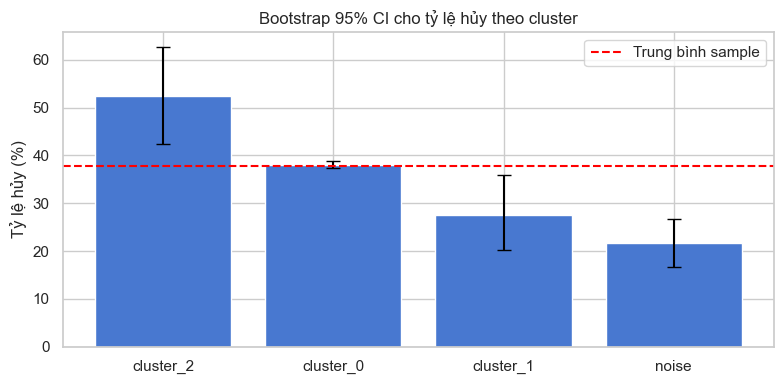

In [9]:
def bootstrap_rate(values, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    rates = [rng.choice(values, len(values), replace=True).mean() for _ in range(n_boot)]
    return np.mean(values), *np.percentile(rates, [2.5, 97.5])


bootstrap_rows = []
for cluster, group in df_analysis.groupby("cluster"):
    mean, low, high = bootstrap_rate(
        group["is_canceled"].to_numpy(), seed=RANDOM_STATE + int(cluster) + 10,
    )
    bootstrap_rows.append({
        "cluster_label": "noise" if cluster == -1 else f"cluster_{cluster}",
        "n": len(group), "cancel_rate": 100 * mean,
        "ci_low": 100 * low, "ci_high": 100 * high,
    })

bootstrap_ci = pd.DataFrame(bootstrap_rows).sort_values("cancel_rate", ascending=False)
display(bootstrap_ci.round(2))

errors = [
    bootstrap_ci["cancel_rate"] - bootstrap_ci["ci_low"],
    bootstrap_ci["ci_high"] - bootstrap_ci["cancel_rate"],
]
plt.figure(figsize=(8, 4))
plt.bar(bootstrap_ci["cluster_label"], bootstrap_ci["cancel_rate"])
plt.errorbar(bootstrap_ci["cluster_label"], bootstrap_ci["cancel_rate"],
             yerr=errors, fmt="none", color="black", capsize=5)
plt.axhline(overall_cancel_rate * 100, color="red", linestyle="--", label="Trung bình sample")
plt.title("Bootstrap 95% CI cho tỷ lệ hủy theo cluster")
plt.ylabel("Tỷ lệ hủy (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_bootstrap_ci.png", dpi=300)
plt.show()

## 7. Phát hiện, hạn chế và khuyến nghị

**Phát hiện chính**

1. Decision Tree là mô hình tốt nhất ở Bài 2; trên sample đã align, dự đoán out-of-fold tiếp tục cho thấy tín hiệu phân loại rõ.
2. `cluster_2` có tỷ lệ hủy và xác suất hủy dự đoán cao nhất; Classification và Clustering xác nhận cùng một nhóm rủi ro.
3. `lead_time`, `total_of_special_requests`, `adr`, `booking_changes` và `total_stay` là các biến nổi bật khi đối chiếu hai kỹ thuật.

**Hạn chế**

- Kết quả thể hiện quan hệ thống kê, không chứng minh quan hệ nhân quả.
- `cluster_1` và `cluster_2` có ít booking; khoảng tin cậy rộng nên chưa thể khái quát mạnh.
- DBSCAN nhạy với cách chuẩn hóa, `eps`, `min_samples` và sample được chọn.

**Khuyến nghị**

1. Dùng xác suất của Classification để cảnh báo sớm và cluster để chọn cách xử lý phù hợp.
2. Ưu tiên xác minh booking thuộc nhóm rủi ro cao trước khi áp dụng chính sách đặt cọc hoặc xác nhận lại.
3. Kiểm tra lại các cluster nhỏ trên nhiều sample hoặc giai đoạn thời gian trước khi triển khai.

## 8. Kết luận

Classification và Clustering bổ sung cho nhau: mô hình phân loại ước lượng rủi ro của từng booking, còn DBSCAN cung cấp nhóm hành vi để giải thích và ưu tiên hành động. Kết quả trên sample thống nhất ở nhóm rủi ro cao, nhưng các cluster nhỏ cần tiếp tục được kiểm chứng bằng dữ liệu mới.